# EI-Beginner 任务二


1. 先学习强化学习基础，并在 `Gymnasium` 环境中训练、测试成功率。
2. 再把思路迁移到机械臂抓取任务，在 `PyBullet/MuJoCo` 中训练抓取策略，并理解 `Sim2Real` 的核心问题。

学习顺序：
- 先完整跑通 `FrozenLake` 和 `CartPole`
- 再阅读机械臂部分，按需安装依赖并尝试 `PandaPickAndPlace`


## 任务要求拆解

任务二目标：

- 学会强化学习中的基本元素：`state`、`action`、`reward`、`policy`、`episode`
- 至少完成几个经典 Gym 任务，并给出训练结果与成功率评估
- 能解释为什么某些任务适合值函数方法，某些任务更适合策略梯度/Actor-Critic
- 能把强化学习流程迁移到机械臂任务中
- 能说明仿真到真实部署（`Sim2Real`）会遇到哪些问题

这个 notebook 的设计是：
- `FrozenLake`：学习离散状态下的 `Q-Learning`
- `CartPole`：学习深度强化学习中的 `PPO`
- `PandaPickAndPlace`：提供机械臂抓取训练模板


In [ ]:
# 如果你缺少依赖，可以取消注释后运行。
# 建议先运行基础部分，机械臂部分最后再装。

# %pip install -U gymnasium stable-baselines3 matplotlib numpy pandas
# %pip install -U panda-gym pybullet


In [2]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym

from collections import defaultdict
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

plt.style.use('ggplot')


## 强化学习最小知识框架

概念：

- `state`：环境当前状态，例如杆子的角度、机械臂末端位置
- `action`：智能体采取的动作，例如向左推/向右推，或机械臂关节控制量
- `reward`：环境给出的即时反馈
- `policy`：从状态到动作的映射规则
- `return`：一段时间内累计得到的奖励
- `value function`：评估某个状态或状态动作对长期收益的价值

常见方法粗分：

- `Q-Learning`：适合离散状态、离散动作的小任务
- `DQN`：用神经网络逼近 Q 值，适合较复杂离散动作任务
- `PPO/SAC/TD3`：更常用于连续控制，例如机械臂、机器人运动控制


## Part A: FrozenLake 上的 Q-Learning

这里用 `FrozenLake-v1` 学强化学习最基本的表格法。它的意义不是性能最强，而是帮助你建立：

- 状态转移
- 探索与利用
- 成功率统计
- Q 表更新


In [ ]:
env = gym.make('FrozenLake-v1', is_slippery=False, render_mode='rgb_array') #try slippery=True for more challenge
obs, info = env.reset(seed=SEED)

print('observation_space:', env.observation_space)
print('action_space:', env.action_space)
print('initial_obs:', obs)


observation_space: Discrete(16)
action_space: Discrete(4)
initial_obs: 0


ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5205:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib conf.c:5205:(_snd_config_evaluate) function snd_func_concat returned error: No such file or directory
ALSA lib confmisc.c:1342:(snd_func_refer) error evaluating name
ALSA lib conf.c:5205:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5728:(snd_config_expand) Evaluate error: No such file or directory
ALSA lib pcm.c:2722:(snd_pcm_open_noupdate) Unknown PCM default


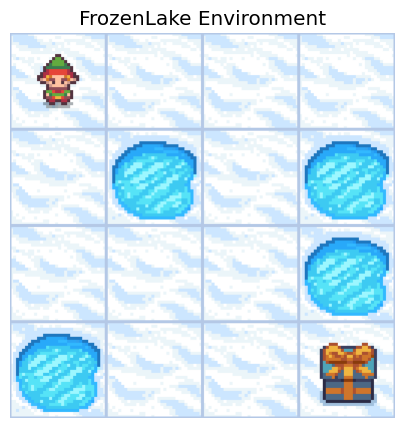

In [ ]:
# 可视化环境
def render_env(env, title=''):
    plt.figure(figsize=(5, 5))
    frame = env.render()
    plt.imshow(frame)
    plt.title(title)
    plt.axis('off')
    plt.show()
render_env(env, title='FrozenLake Environment')

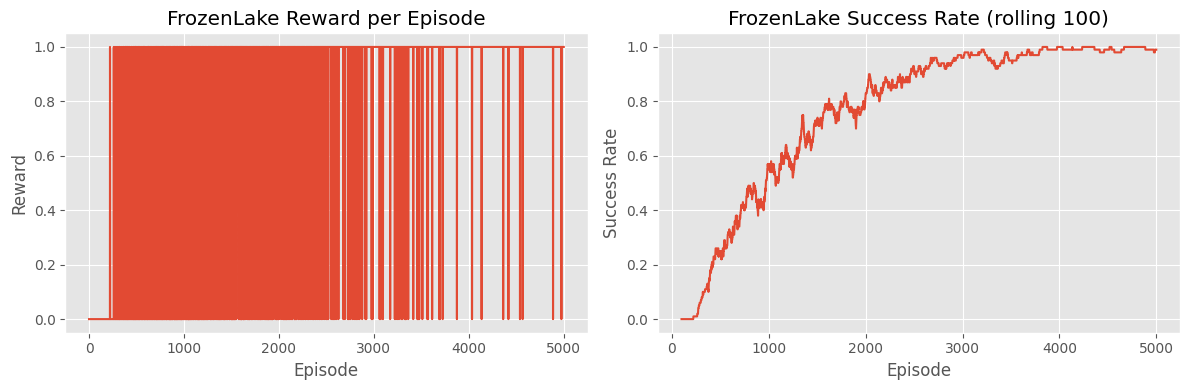

Final Q-Table:
[[0.94148015 0.95099005 0.9320653  0.94148015]
 [0.94148014 0.         0.60163129 0.82758327]
 [0.17803574 0.91625007 0.03284318 0.19930953]
 [0.22195584 0.         0.00260934 0.00666985]
 [0.95099005 0.96059601 0.         0.94148015]
 [0.         0.         0.         0.        ]
 [0.         0.98008461 0.         0.60723813]
 [0.         0.         0.         0.        ]
 [0.960596   0.         0.970299   0.95099003]
 [0.96059569 0.98009961 0.9801     0.        ]
 [0.97029793 0.99       0.         0.97016556]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.88552258 0.99       0.84561816]
 [0.98009195 0.98999061 1.         0.98009739]
 [0.         0.         0.         0.        ]]


In [ ]:
def q_learning_train(
    env,
    episodes=5000,
    alpha=0.1,
    gamma=0.99,
    epsilon_start=1.0,
    epsilon_end=0.01,
    epsilon_decay=0.999,
):
    q_table = np.zeros((env.observation_space.n, env.action_space.n))
    epsilon = epsilon_start
    rewards = []
    success_history = []

    for episode in range(episodes):
        state, _ = env.reset()
        done = False
        total_reward = 0.0

        while not done:
            if np.random.rand() < epsilon:
                action = env.action_space.sample()
            else:
                action = int(np.argmax(q_table[state]))

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            best_next_q = np.max(q_table[next_state])
            td_target = reward + gamma * best_next_q * (0 if done else 1)
            td_error = q_table[state, action] - td_target
            q_table[state, action] -= alpha * td_error

            state = next_state
            total_reward += reward

        epsilon = max(epsilon_end, epsilon * epsilon_decay)
        rewards.append(total_reward)
        success_history.append(1 if total_reward > 0 else 0)

    return q_table, rewards, success_history


q_table, rewards, success_history = q_learning_train(env)

window = 100
rolling_success = pd.Series(success_history).rolling(window).mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(rewards)
axes[0].set_title('FrozenLake Reward per Episode')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Reward')

axes[1].plot(rolling_success)
axes[1].set_title(f'FrozenLake Success Rate (rolling {window})')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Success Rate')

plt.tight_layout()
plt.show()

print('Final Q-Table:')
print(q_table)

In [ ]:
def evaluate_q_policy(env, q_table, episodes=500):
    success = 0
    rewards = []

    for _ in range(episodes):
        state, _ = env.reset()
        done = False
        total_reward = 0.0

        while not done:
            action = int(np.argmax(q_table[state]))
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total_reward += reward

        rewards.append(total_reward)
        success += int(total_reward > 0)

    return {
        'episodes': episodes,
        'success_rate': success / episodes,
        'mean_reward': float(np.mean(rewards)),
    }


frozenlake_result = evaluate_q_policy(env, q_table)
frozenlake_result


{'episodes': 500, 'success_rate': 1.0, 'mean_reward': 1.0}

### 你应该从 FrozenLake 学到什么

- 强化学习不是监督学习，没有标准答案标签，而是通过交互拿奖励
- 训练曲线通常不稳定，成功率比单次 reward 更能说明策略质量
- 表格法适合理解原理，但难以扩展到高维视觉/连续控制任务

这就是为什么后面机械臂抓取通常不会只用 `Q-Learning`，而会转向 `PPO`、`SAC`、`TD3` 等方法。

## Part B: CartPole 上的 PPO

`CartPole-v1` 是一个经典控制任务，适合用来理解深度强化学习训练流程。这里我们使用 `stable-baselines3` 的 `PPO`，重点关注：

- 环境创建
- 模型训练
- 平均回报和成功率评估
- 为什么策略梯度方法更容易迁移到机器人控制


observation_space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
action_space: Discrete(2)


ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5205:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib conf.c:5205:(_snd_config_evaluate) function snd_func_concat returned error: No such file or directory
ALSA lib confmisc.c:1342:(snd_func_refer) error evaluating name
ALSA lib conf.c:5205:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5728:(snd_config_expand) Evaluate error: No such file or directory
ALSA lib pcm.c:2722:(snd_pcm_open_noupdate) Unknown PCM default


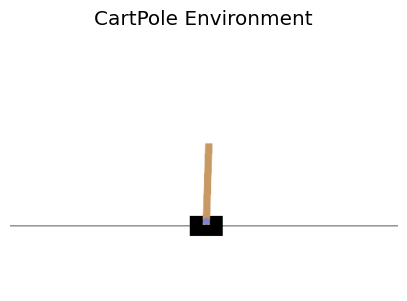

In [ ]:
cartpole_env = gym.make('CartPole-v1', render_mode='rgb_array')

print('observation_space:', cartpole_env.observation_space) #min and max values for each state variable
print('action_space:', cartpole_env.action_space)

obs, info = cartpole_env.reset(seed=SEED)
render_env(cartpole_env, title='CartPole Environment')

In [ ]:
model = PPO('MlpPolicy', cartpole_env, verbose=0, seed=SEED)
model.learn(total_timesteps=20_000)

/home/wzb/miniconda3/envs/vlash/lib/python3.10/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


In [ ]:
eval_env = gym.make('CartPole-v1', render_mode='rgb_array')
mean_reward, std_reward = evaluate_policy(model, eval_env, n_eval_episodes=50)

success_threshold = 475
episode_rewards = []
success_count = 0

for _ in range(50):
    obs, _ = eval_env.reset()
    done = False
    total_reward = 0.0

    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, _ = eval_env.step(action)
        done = terminated or truncated
        total_reward += reward

    episode_rewards.append(total_reward)
    if total_reward >= success_threshold:
        success_count += 1

cartpole_result = {
    'mean_reward': float(mean_reward),
    'std_reward': float(std_reward),
    'success_threshold': success_threshold,
    'success_rate': success_count / 50,
}

cartpole_result


/home/wzb/miniconda3/envs/vlash/lib/python3.10/site-packages/stable_baselines3/common/evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


{'mean_reward': 500.0,
 'std_reward': 0.0,
 'success_threshold': 475,
 'success_rate': 1.0}

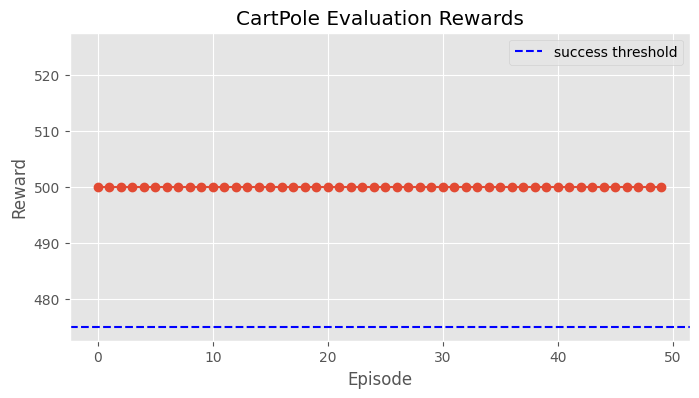

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(episode_rewards, marker='o')
plt.axhline(success_threshold, color='blue', linestyle='--', label='success threshold')
plt.title('CartPole Evaluation Rewards')
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.legend()
plt.show()


In [30]:
# 生成一个演示视频
def create_cartpole_video(model, env, filename='demo.mp4'):
    frames = []
    obs, info = env.reset()
    done = False

    while not done:
        frame = env.render()
        frames.append(frame)
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

    dist = np.linalg.norm(obs["achieved_goal"] - obs["desired_goal"])
    print("final distance:", dist)
    print("is_success:", info.get("is_success"))

    # Save frames as video
    import mediapy
    from IPython.display import Video, display
    mediapy.write_video(filename, frames, fps=10)
    display(Video(filename, embed=True))

In [ ]:
create_cartpole_video(model, eval_env)

### 为什么 CartPole 对机械臂任务有启发

- `CartPole` 是低维状态控制问题，机械臂则通常是更高维连续控制问题
- 两者都需要通过长期累计奖励学习稳定策略
- 机器人任务常见挑战包括稀疏奖励、探索困难、训练不稳定



## Part C: 机械臂抓取任务模板（PyBullet）

这里提供一个适合继续扩展的机械臂任务模板。为了方便入门，这里优先使用 `panda-gym`

常见实践建议：

- 先跑 `Reach` 再跑 `PickAndPlace`
- 先让 reward 密集一些（dense reward），再尝试稀疏奖励
- 先在仿真里稳定训练，再考虑真实机械臂部署


In [ ]:
%pip install panda_gym

  Using cached panda_gym-3.0.7-py3-none-any.whl.metadata (4.3 kB)
Using cached panda_gym-3.0.7-py3-none-any.whl (23 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 MB 20.5 MB/s  0:00:05m0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [panda_gym]
Note: you may need to restart the kernel to use updated packages.


In [36]:
import gymnasium as gym
import panda_gym
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv

def make_env():
    return gym.make("PandaReachDense-v3")

vec_env = DummyVecEnv([make_env for _ in range(8)])

model = PPO(
    "MultiInputPolicy",
    vec_env,
    verbose=1,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=256,
    gamma=0.98,
    gae_lambda=0.95,
    ent_coef=0.0,
    seed=SEED,
)

model.learn(total_timesteps=200_000)

argv[0]=--background_color_red=0.8745098114013672
argv[1]=--background_color_green=0.21176470816135406
argv[2]=--background_color_blue=0.1764705926179886
argv[0]=--background_color_red=0.8745098114013672
argv[1]=--background_color_green=0.21176470816135406
argv[2]=--background_color_blue=0.1764705926179886
argv[0]=--background_color_red=0.8745098114013672
argv[1]=--background_color_green=0.21176470816135406
argv[2]=--background_color_blue=0.1764705926179886
argv[0]=--background_color_red=0.8745098114013672
argv[1]=--background_color_green=0.21176470816135406
argv[2]=--background_color_blue=0.1764705926179886
argv[0]=--background_color_red=0.8745098114013672
argv[1]=--background_color_green=0.21176470816135406
argv[2]=--background_color_blue=0.1764705926179886
argv[0]=--background_color_red=0.8745098114013672
argv[1]=--background_color_green=0.21176470816135406
argv[2]=--background_color_blue=0.1764705926179886
argv[0]=--background_color_red=0.8745098114013672
argv[1]=--background_color

In [38]:
eval_env = gym.make("PandaReachDense-v3", render_mode='rgb_array')
mean_reward, std_reward = evaluate_policy(model, eval_env, n_eval_episodes=20)
print(f"Mean reward: {mean_reward:.2f} +/- {std_reward:.2f}")

create_cartpole_video(model, eval_env)

argv[0]=--background_color_red=0.8745098114013672
argv[1]=--background_color_green=0.21176470816135406
argv[2]=--background_color_blue=0.1764705926179886
Mean reward: -0.24 +/- 0.14
final distance: 0.04101459
is_success: True


In [3]:
import gymnasium as gym
import panda_gym
import numpy as np

from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.monitor import Monitor

def make_pick_env():
    return Monitor(gym.make("PandaPickAndPlaceDense-v3"))

train_env = DummyVecEnv([make_pick_env for _ in range(32)])

pick_model = PPO(
    "MultiInputPolicy",
    train_env,
    verbose=1,
    device="cuda",
    learning_rate=1e-4,
    n_steps=1024,
    batch_size=1024,
    gamma=0.98,
    gae_lambda=0.95,
    ent_coef=0.01,
    seed=SEED,
)

pick_model.learn(total_timesteps=10_000_000)


argv[0]=--background_color_red=0.8745098114013672
argv[1]=--background_color_green=0.21176470816135406
argv[2]=--background_color_blue=0.1764705926179886
argv[0]=--background_color_red=0.8745098114013672
argv[1]=--background_color_green=0.21176470816135406
argv[2]=--background_color_blue=0.1764705926179886
argv[0]=--background_color_red=0.8745098114013672
argv[1]=--background_color_green=0.21176470816135406
argv[2]=--background_color_blue=0.1764705926179886
argv[0]=--background_color_red=0.8745098114013672
argv[1]=--background_color_green=0.21176470816135406
argv[2]=--background_color_blue=0.1764705926179886
argv[0]=--background_color_red=0.8745098114013672
argv[1]=--background_color_green=0.21176470816135406
argv[2]=--background_color_blue=0.1764705926179886
argv[0]=--background_color_red=0.8745098114013672
argv[1]=--background_color_green=0.21176470816135406
argv[2]=--background_color_blue=0.1764705926179886
argv[0]=--background_color_red=0.8745098114013672
argv[1]=--background_color

KeyboardInterrupt: 

In [ ]:
eval_env = gym.make("PandaPickAndPlaceDense-v3")

successes = []
episode_rewards = []

for _ in range(50):
    obs, info = eval_env.reset()
    done = False
    total_reward = 0.0
    final_success = 0.0

    while not done:
        action, _ = pick_model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = eval_env.step(action)
        done = terminated or truncated
        total_reward += reward
        final_success = info.get("is_success", final_success)

    successes.append(float(final_success))
    episode_rewards.append(total_reward)

print({
    "mean_reward": float(np.mean(episode_rewards)),
    "success_rate": float(np.mean(successes)),
})

In [ ]:
# 生成视频
create_cartpole_video(pick_model, eval_env)

This browser does not support the video tag.


## Sim2Real 应该重点理解什么

即使仿真里学会抓取，真实机械臂仍然可能失败，核心原因通常包括：

- 动力学不一致：摩擦、碰撞、质量参数和真实世界不完全相同
- 视觉偏差：真实相机噪声、光照、遮挡更复杂
- 控制延迟：真实系统存在通信和执行器延迟
- 安全约束：真实机械臂不能像仿真一样随便探索

常见缓解方法：

- `domain randomization`
- 更准确的系统辨识
- 从 `reach -> grasp -> pick-and-place` 逐步增加任务难度
- 先离线评估，再小心上线真机
